<a href="https://colab.research.google.com/github/Satyabratadas/GeoEmerge_hackathon/blob/master/analysis_Matthew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd                           # For working with data
pd.set_option("display.max_columns", None)    # Lets us see all columns of the data instead of just a preview
import geopandas as gpd                       # For working with spatial data
import numpy as np                            # For working with numbers
import matplotlib.pyplot as plt               # For making graphs
from datetime import date                     # For formatting dates
from PIL import Image                         # For getting and displaying images from links
import requests                               # For getting information from links
from io import BytesIO                        # For working with types of input and output

import seaborn as sns
import folium
from folium.plugins import HeatMap


end_date = "2026-01-31"

data = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=mosquito_habitat_mapper&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")

In [18]:
#mosquito = gpd.read_file('https://github.com/geo-di-lab/emerge-lessons/raw/refs/heads/main/docs/data/globe_mosquito.zip')
land_cover = gpd.read_file(f"https://api.globe.gov/search/v1/measurement/?protocols=land_covers&datefield=measuredDate&startdate=2018-01-01&enddate={end_date}&geojson=TRUE&sample=FALSE")




In [19]:
land_cover

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
0,USA,United States,6.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89459,true,52,automatic,2026-01-31 03:33:00.000,7.3,21.3247,-158.0259,null,null,,true,null,null,null,https://data.globe.gov/system/photos/2026/01/3...,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178265728,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,408348,04QFJ010583,POINT (-158.0261 21.32383)
1,USA,United States,2.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89458,true,32,automatic,2026-01-31 03:02:00.000,4.3,21.3173,-157.8621,null,null,,false,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178386707,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409681,04QFJ180576,POINT (-157.86225 21.31648)
2,USA,United States,265.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/3...,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89457,true,25,automatic,2026-01-31 00:19:00.000,271,21.4798,-157.9967,null,null,,true,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178357780,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409676,04QFJ039755,POINT (-157.99708 21.47905)
3,USA,United States,7.9,GLOBE Data Entry Site Definition,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,None,89460,null,null,null,2026-01-31 03:49:22.993,None,None,None,M9,Urban,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,17043304,United States of America Citizen Science,land_covers,409682,Park,POINT (-158.0261 21.325)
4,USA,United States,159.2,GLOBE Observer App,null,null,pending approval,false,null,"60% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,https://data.globe.gov/system/photos/2026/01/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),[Oregon State University GEOGRAPHY],89456,true,12,automatic,2026-01-31 00:26:00.000,152.7,47.428,-122.0285,M43,"Herba

In [36]:
florida_only = land_cover[
    (land_cover["countryCode"] == "USA") & (land_cover.geometry.x.between(-87.7, -79.6)) & (land_cover.geometry.y.between(24.4, 31.1))
].copy()

In [40]:
florida_only.shape

(690, 63)

In [23]:
florida_only

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
602,USA,United States,51.2,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 231, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 312, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 314, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Standing decidusous broadleaf trees,"((compassData.heading: 169, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Cutdown trees to west.,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88833,true,5,automatic,2026-01-02 19:47:00.000,48.3,28.6467,-81.7105,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407606,17RMM305690,POINT (-81.71114 28.64624)
606,USA,United States,41.4,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/0...,true,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 287, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 67, compassData.horizon...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 155, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,null,"((compassData.heading: 227, compassData.horizo...",https://data.globe.gov/system/photos/2026/01/0...,Observation tower at tree canopy height. Everg...,"[HTLC, OpeningTheAperture EarthAsArt, Oregon H...",88836,true,5,automatic,2026-01-02 19:34:00.000,34.7,28.6474,-81.7085,null,null,,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,false,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,false,null,null,https://data.globe.gov/system/photos/2026/01/0...,8267248,null,null,null,https://data.globe.gov/system/photos/2026/01/0...,32402168,"College of Earth, Ocean, Atmospheric Sciences ...",land_covers,407608,17RMM307691,POINT (-81.7091 28.64716)
607,USA,United States,41.4,GLOBE Observer App,null,null,null,true,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Duplicate location with

In [41]:
fl_data = data[data["countryName"] == "United States"].copy()
fl_data = fl_data.cx[-87.7:-79.6, 24.4:31.1]  #FL bounding box
fl_data = fl_data.rename(columns={"siteId": "siteId"})

In [43]:
fl_data.shape

(625, 35)

In [44]:
merged = pd.merge(florida_only, fl_data, on="siteId")

In [45]:
merged.shape

(178, 97)

In [16]:
#urban=
#farmland=


SyntaxError: invalid syntax (ipython-input-3132458695.py, line 1)

In [46]:
merged.columns

Index(['countryCode_x', 'countryName_x', 'elevation_x', 'landcoversDataSource',
       'landcoversDownwardCaption', 'landcoversDownwardExtraData',
       'landcoversDownwardPhotoUrl', 'landcoversDryGround',
       'landcoversEastCaption', 'landcoversEastClassifications',
       'landcoversEastExtraData', 'landcoversEastPhotoUrl',
       'landcoversFeature1Caption', 'landcoversFeature1ExtraData',
       'landcoversFeature1PhotoUrl', 'landcoversFeature2Caption',
       'landcoversFeature2ExtraData', 'landcoversFeature2PhotoUrl',
       'landcoversFeature3Caption', 'landcoversFeature3ExtraData',
       'landcoversFeature3PhotoUrl', 'landcoversFeature4Caption',
       'landcoversFeature4ExtraData', 'landcoversFeature4PhotoUrl',
       'landcoversFieldNotes', 'landcoversGlobeTeams', 'landcoversLandCoverId',
       'landcoversLeavesOnTrees', 'landcoversLocationAccuracyM',
       'landcoversLocationMethod', 'landcoversMeasuredAt',
       'landcoversMeasurementElevation', 'landcoversMeasuremen

In [51]:
df = merged.copy()

,countryCode_x,countryName_x,elevation_x,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId_x,organizationName_x,protocol_x,siteId,siteName_x,geometry_x,countryCode_y,countryName_y,elevation_y,mosquitohabitatmapperAbdomenCloseupPhotoUrls,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperComments,mosquitohabitatmapperDataSource,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperGlobeTeams,mosquitohabitatmapperLarvaFullBodyPhotoUrls,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperLastIdentifyStage,mosquitohabitatmapperLocationAccuracyM,mosquitohabitatmapperLocationMethod,mosquitohabitatmapperMeasuredAt,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMeasurementLatitude,mosquitohabitatmapperMeasurementLongitude,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggCount,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoHabitatMapperId,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperUserid,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourcePhotoUrls,mosquitohabitatmapperWaterSourceType,organizationId_y,organizationName_y,protocol_y,siteName_y,geometry_y
0,USA,United States,2.8,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2025/10/0...,false,null,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,null,null,null,null,null,null,null,null,null,null,null,null,House and yard on canal,None,86094,true,null,manual,2025-10-05 22:55:00,2,26.2152,-80.2169,M91,"Urban, Residential Property",,false,null,"10% MUC 02 (n) [Trees, Closely Spaced, Deciduo...",null,https://data.globe.gov/system/photos/2025/10/0...,false,false,null,"30% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,false,null,null,https://data.globe.gov/system/photos/2025/10/0...,171829152,null,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",null,https://data.globe.gov/system/photos/2025/10/0...,10532858,GLOBE Implementation Office GLOBE v-School,land_covers,400104,17RNJ782997,POINT (-80.21719 26.21473),USA,United States,2.8,null,false,Canal in City running from inland to ocean.,GLOBE Observer App,LarvaeVisibleNo,null,None,null,0,null,20,automatic,2025-10-08 12:15:00,0,26.2154,-80.2169,null,null,null,48840,false,null,171829152,"puddle or still water next to a creek, stream ...",null,flowing: still water found next to river or st...,10532858,GLOBE Implementation Office GLOBE v-School,mosquito_habitat_mapper,17RNJ782997,POINT (-80.21719 26.21473)
1,USA,United States,6.4,GLOBE Observer App,null,null,https://data.globe.gov/system/pho

In [68]:
keep_cols = [
    "siteId",
    "elevation_x",
    "landcoversDryGround",
    "landcoversEastClassifications",
    "landcoversLeavesOnTrees",
    "landcoversMeasurementElevation",
    "landcoversMeasurementLatitude",
    "landcoversMeasurementLongitude",
    "landcoversMucCode",
    "landcoversMucDescription",
    "landcoversMuddy",
    "landcoversNorthClassifications",
    "landcoversRainingSnowing",
    "landcoversSnowIce",
    "landcoversSouthClassifications",
    "landcoversStandingWater",
    "landcoversWestClassifications",
    "mosquitohabitatmapperBreedingGroundEliminated",
    "mosquitohabitatmapperExtraData",
    "mosquitohabitatmapperGenus",
    "mosquitohabitatmapperLarvaeCount",
    "mosquitohabitatmapperMeasurementElevation",
    "mosquitohabitatmapperMosquitoAdults",
    "mosquitohabitatmapperMosquitoEggs",
    "mosquitohabitatmapperMosquitoPupae",
    "mosquitohabitatmapperSpecies",
    "mosquitohabitatmapperWaterSource",
    "mosquitohabitatmapperWaterSourceType",
    "mosquitohabitatmapperMeasuredAt",
    "landcoversMeasuredAt"
]
df_model = df[[c for c in keep_cols if c in df.columns]].copy()

In [69]:
df_model

,siteId,elevation_x,landcoversDryGround,landcoversEastClassifications,landcoversLeavesOnTrees,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMuddy,landcoversNorthClassifications,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthClassifications,landcoversStandingWater,landcoversWestClassifications,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourceType,mosquitohabitatmapperMeasuredAt,landcoversMeasuredAt
0,400104,2.8,false,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",true,2,26.2152,-80.2169,M91,"Urban, Residential Property",false,"10% MUC 02 (n) [Trees, Closely Spaced, Deciduo...",false,false,"30% MUC 01 (b) [Trees, Closely Spaced, Evergre...",false,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",false,LarvaeVisibleNo,null,0,0,null,null,false,null,"puddle or still water next to a creek, stream ...",flowing: still water found next to river or st...,2025-10-08 12:15:00,2025-10-05 22:55:00
1,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleYes,null,31,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-29 20:27:00,2023-06-15 15:35:00
2,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleNo,null,0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:17:00,2023-06-15 15:35:00
3,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleNo,null,0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:16:00,2023-06-15 15:35:00
4,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleYes,null,21,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:21:00,2023-06-15 15:35:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,163669,3.3,true,null,true,3.2,26.3345,-80.1144,null,null,false,null,false,false,null,true,null,false,null,null,0,0,true,false,false,null,jar,container: artificial,2019-08-02 22:50:00,2019-07-27 18:24:00
174,163669,3.3,true,null,true,3.2,26.3345,-80.1144,null,null,false,null,false,false,null,true,null,false,null,null,0,0,true,false,false,null,jar,container: artificial,2019-08-02 22:46:00,2019-07-27 18:24:00
175,163669,3.3,true,null,true,3.2,26.3345,-80.1144,null,null,false,null,false,false,null,true,null,false,null,null,0,0,true,false,false,null,jar,container: artificial,2019-08-02 22:49:00,2019-07-27 18:24:00
176,163669,3.3,true,null,true,3.2,26.3345,-80.1144,null,null,false,null,false,false,null,true,null,false,null,null,0,0,true,false,false,null,"puddle, vehhicle or animal tracks",still: lake/pond/swamp,2019-07-31 14:04:00,2019-07-27 18:24:00


In [80]:
df_model.head()


,siteId,elevation_x,landcoversDryGround,landcoversEastClassifications,landcoversLeavesOnTrees,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMuddy,landcoversNorthClassifications,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthClassifications,landcoversStandingWater,landcoversWestClassifications,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperExtraData,mosquitohabitatmapperGenus,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperMeasurementElevation,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoPupae,mosquitohabitatmapperSpecies,mosquitohabitatmapperWaterSource,mosquitohabitatmapperWaterSourceType,mosquitohabitatmapperMeasuredAt,landcoversMeasuredAt
0,400104,2.8,false,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",true,2,26.2152,-80.2169,M91,"Urban, Residential Property",false,"10% MUC 02 (n) [Trees, Closely Spaced, Deciduo...",false,false,"30% MUC 01 (b) [Trees, Closely Spaced, Evergre...",false,"10% MUC 01 (b) [Trees, Closely Spaced, Evergre...",false,LarvaeVisibleNo,null,0.0,0,null,null,false,null,"puddle or still water next to a creek, stream ...",flowing: still water found next to river or st...,2025-10-08 12:15:00,2025-10-05 22:55:00
1,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleYes,null,31.0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-29 20:27:00,2023-06-15 15:35:00
2,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleNo,null,0.0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:17:00,2023-06-15 15:35:00
3,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleNo,null,0.0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:16:00,2023-06-15 15:35:00
4,317215,6.4,true,null,true,6,27.5877,-80.4441,null,null,true,null,false,false,null,false,null,true,LarvaeVisibleYes,null,21.0,0,null,null,false,null,"cement, metal or plastic tank",container: artificial,2023-06-22 19:21:00,2023-06-15 15:35:00


In [81]:
df_corr = df_model.copy()
df_corr = df_corr.drop(columns=["mosquitohabitatmapperExtraData"], errors="ignore")

In [82]:
bool_cols = [
    "landcoversDryGround",
    "landcoversLeavesOnTrees",
    "landcoversMuddy",
    "landcoversRainingSnowing",
    "landcoversSnowIce",
    "landcoversStandingWater",
    "mosquitohabitatmapperBreedingGroundEliminated",
    "mosquitohabitatmapperMosquitoAdults",
    "mosquitohabitatmapperMosquitoEggs",
    "mosquitohabitatmapperMosquitoPupae",
]

for c in bool_cols:
    if c in df_corr.columns:
        df_corr[c] = df_corr[c].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)

In [83]:
df_corr["mosquito_measuredAt"] = pd.to_datetime(df_corr["mosquitohabitatmapperMeasuredAt"], errors="coerce")
df_corr["landcover_measuredAt"] = pd.to_datetime(df_corr["landcoversMeasuredAt"], errors="coerce")

df_corr["mosquito_month"] = df_corr["mosquito_measuredAt"].dt.month
df_corr["mosquito_year"] = df_corr["mosquito_measuredAt"].dt.year

df_corr = df_corr.drop(columns=["mosquitohabitatmapperMeasuredAt", "landcoversMeasuredAt"], errors="ignore")


In [84]:
cat_cols = [
    "landcoversMucCode",
    "landcoversMucDescription",
    "mosquitohabitatmapperGenus",
    "mosquitohabitatmapperSpecies",
    "mosquitohabitatmapperWaterSourceType",
]

df_encoded = pd.get_dummies(
    df_corr,
    columns=[c for c in cat_cols if c in df_corr.columns],
    drop_first=True
)

In [88]:
df_encoded = df_encoded.drop(columns=["siteId"], errors="ignore")

corr_matrix = df_encoded.corr(numeric_only=True)
corr_matrix

,landcoversDryGround,landcoversLeavesOnTrees,landcoversMuddy,landcoversRainingSnowing,landcoversSnowIce,landcoversStandingWater,mosquitohabitatmapperBreedingGroundEliminated,mosquitohabitatmapperLarvaeCount,mosquitohabitatmapperMosquitoAdults,mosquitohabitatmapperMosquitoEggs,mosquitohabitatmapperMosquitoPupae,mosquito_month,mosquito_year,landcoversMucCode_M31,landcoversMucCode_M43,landcoversMucCode_M91,landcoversMucCode_null,"landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen","landcoversMucDescription_Shrubs, Closely Spaced, Tall Evergreen","landcoversMucDescription_Urban, Residential Property",landcoversMucDescription_null,mosquitohabitatmapperGenus_Anopheles,mosquitohabitatmapperGenus_Culex,mosquitohabitatmapperGenus_null,mosquitohabitatmapperSpecies_null,mosquitohabitatmapperWaterSourceType_container: natural,mosquitohabitatmapperWaterSourceType_flowing: still water found next to river or stream,mosquitohabitatmapperWaterSourceType_still: lake/pond/swamp
landcoversDryGround,1.000000,-0.041770,-0.062049,-0.132817,NaN,0.286631,-0.156437,-0.356289,0.082113,-0.351930,-0.378304,0.221782,-0.409425,-0.135257,-0.066292,-0.030028,0.159858,-0.135257,-0.135257,-0.030028,0.159858,-0.145762,-0.066292,0.113315,-0.059240,0.103793,-0.030028,-0.074008
landcoversLeavesOnTrees,-0.041770,1.000000,-0.195126,0.009841,NaN,-0.088085,0.068686,0.036029,0.052926,0.019291,0.021961,0.063792,-0.085092,0.005650,0.008013,0.009841,-0.015208,0.005650,0.005650,0.009841,-0.015208,0.012778,0.008013,-0.017346,-0.008013,0.014039,0.009841,-0.146731
landcoversMuddy,-0.062049,-0.195126,1.000000,0.209784,NaN,0.281831,0.186114,-0.142738,-0.128923,0.179361,0.074100,-0.210408,0.170643,-0.028954,0.117835,-0.050436,-0.094397,-0.028954,0.195126,-0.050436,-0.094397,-0.065488,0.276733,-0.216869,-0.276733,-0.071946,0.209784,0.504335
landcoversRainingSnowing,-0.132817,0.009841,0.209784,1.000000,NaN,0.065049,-0.032004,-0.051168,0.000521,-0.033603,-0.038255,-0.284625,0.115285,0.574079,-0.013957,-0.017143,-0.198049,0.574079,-0.009841,-0.017143,-0.198049,-0.022259,-0.013957,0.030215,0.013957,-0.024454,0.321905,0.148039
landcoversSnowIce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
landcoversStandingWater,0.286631,-0.088085,0.281831,0.065049,NaN,1.000000,-0.002952,-0.274052,0.535128,-0.029997,-0.080257,0.282188,-0.339182,-0.064139,0.016980,-0.111726,0.055576,-0.064139,0.088085,-0.111726,0.055576,-0.145069,0.124924,-0.010794,-0.124924,-0.159376,0.065049,0.291888
mosquitohabitatmapperBreedingGroundEliminated,-0.156437,0.068686,0.186114,-0.032004,NaN,-0.002952,1.000000,0.135658,0.195362,0.140296,0.277823,0.121447,0.174546,0.082254,0.009621,0.055638,-0.047282,0.082254,-0.068686,0.055638,-0.047282,0.117761,0.116655,-0.201044,-0.116655,-0.045654,-0.032004,-0.051075
mosquitohabitatmapperLarvaeCount,-0.356289,0.036029,-0.142738,-0.051168,NaN,-0.274052,0.135658,1.000000,-0.011252,0.283398,0.273056,-0.213925,0.334907,-0.036029,-0.051168,-0.062935,0.097076,-0.036029,-0.034109,-0.062935,0.097076,-0.007715,-0.048441,0.052279,0.047078,-0.049520,-0.051168,-0.229565
mosquitohabitatmapperMosquitoAdults,0.082113,0.052926,-0.128923,0.000521,NaN,0.535128,0.195362,-0.011252,1.000000,0.116670,0.193275,0.505502,-0.436845,0.106748,0.038166,-0.092192,-0.041739,0.106748,0.106748,-0.092192,-0.041739,-0.119706,-0.075060,0.053552,-0.151393,-0.065384,-0.092192,-0.066588
mosquitohabitatmapperMosquitoEggs,-0.351930,0.019291,0.179361,-0.033603,NaN,-0.029997,0.140296,0.283398,0.116670,1.000000,0.271703,-0.125062,0.220110,-0.019291,0.193999,-0.033603,-0.188149,-0.019291,0.292870,-0.033603,-0.188149,-0.043631,-0.027359,-0.153750,-0.415356,-0.047935,-0.033603,0.098522


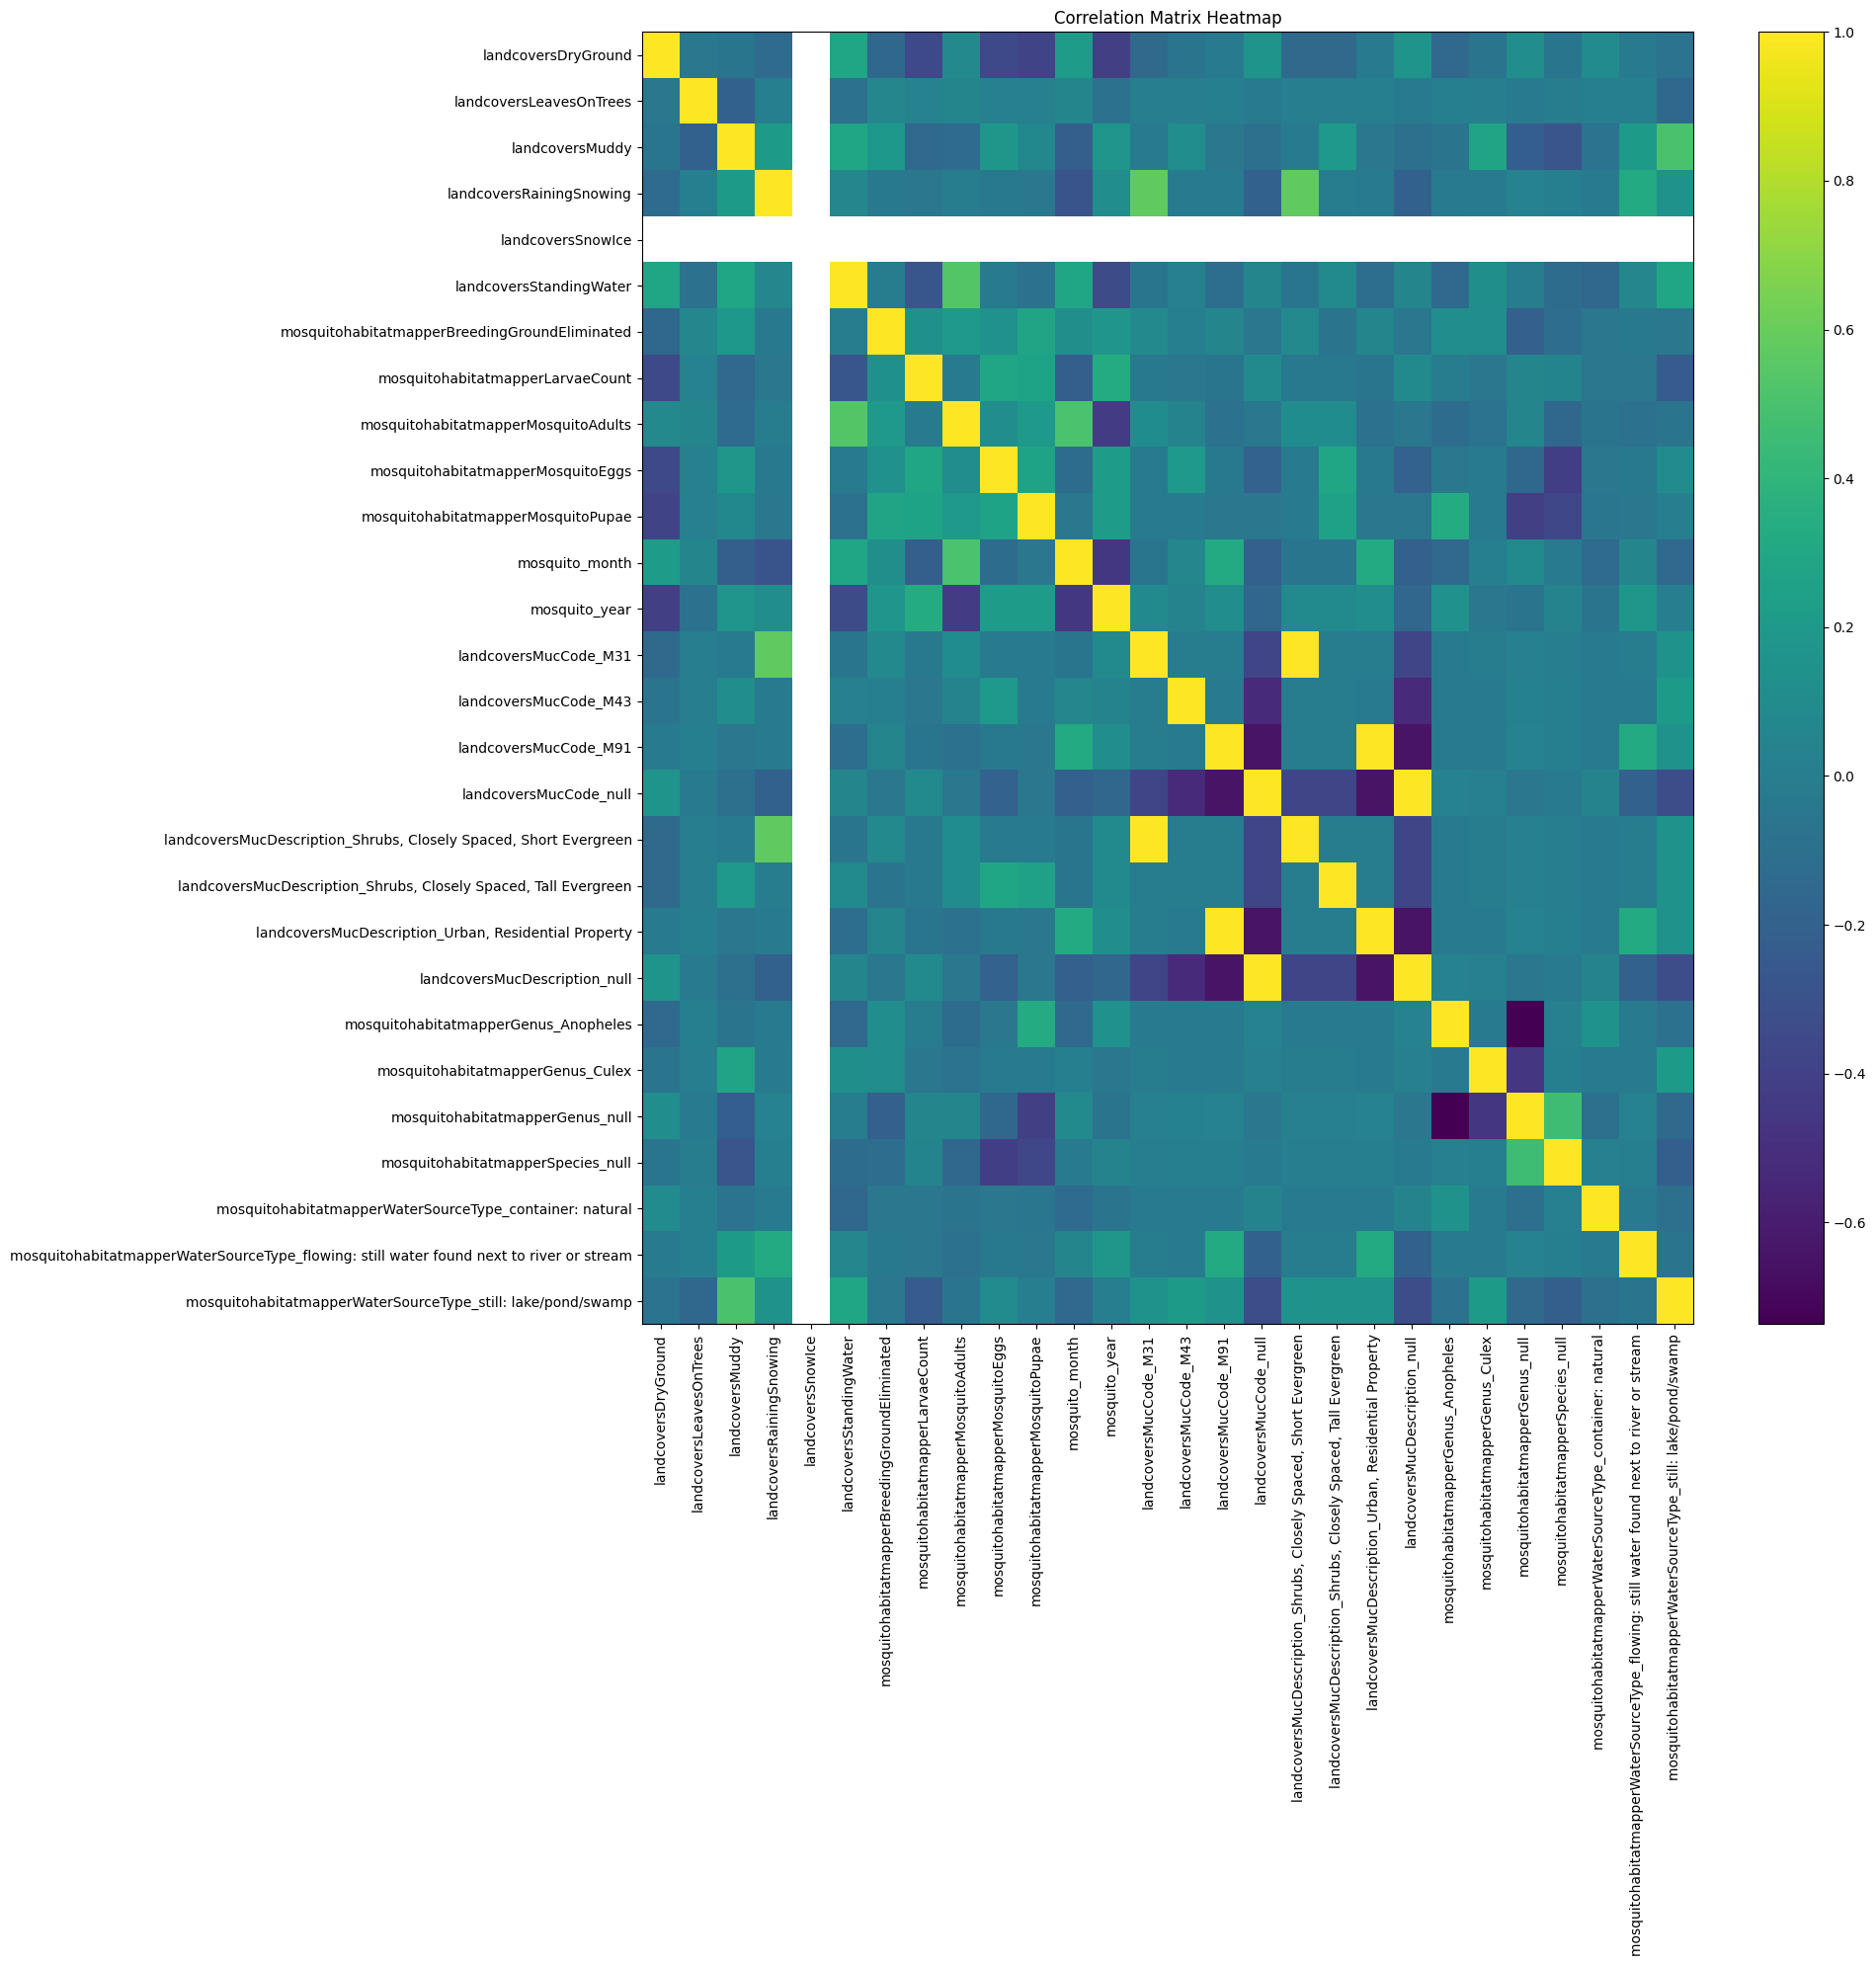

In [92]:
plt.figure(figsize=(20, 20))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [101]:

corr_abs = corr_matrix.abs()

# mask upper triangle + diagonal so you only keep each pair once
mask = np.triu(np.ones_like(corr_abs, dtype=bool))
corr_filtered = corr_abs.mask(mask)

top_pairs = (
    corr_filtered.stack()
    .sort_values(ascending=False)
    .head(40)
)

top_pairs

landcoversMucDescription_Urban, Residential Property                                     landcoversMucCode_M91                                               1.000000
landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen                         landcoversMucCode_M31                                               1.000000
landcoversMucDescription_null                                                            landcoversMucCode_null                                              1.000000
mosquitohabitatmapperGenus_null                                                          mosquitohabitatmapperGenus_Anopheles                                0.736689
landcoversMucDescription_Urban, Residential Property                                     landcoversMucCode_null                                              0.647129
landcoversMucCode_null                                                                   landcoversMucCode_M91                                               0.647129
landcoversMucDescription_null                                                            landcoversMucCode_M91                                               0.647129
                                                                                         landcoversMucDescription_Urban, Residential Property                0.647129
landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen                         landcoversRainingSnowing                                            0.574079
landcoversMucCode_M31                                                                    landcoversRainingSnowing                                            0.574079
mosquitohabitatmapperMosquitoAdults                                                      landcoversStandingWater                                             0.535128
landcoversMucDescription_null                                                            landcoversMucCode_M43                                               0.526875
landcoversMucCode_null                                                                   landcoversMucCode_M43                                               0.526875
mosquito_month                                                                           mosquitohabitatmapperMosquitoAdults                                 0.505502
mosquitohabitatmapperWaterSourceType_still: lake/pond/swamp                              landcoversMuddy                                                     0.504335
mosquitohabitatmapperGenus_null                                                          mosquitohabitatmapperGenus_Culex                                    0.461935
mosquitohabitatmapperSpecies_null                                                        mosquitohabitatmapperGenus_null                                     0.461935
mosquito_year                                                                            mosquito_month                                                      0.455112
                                                                                         mosquitohabitatmapperMosquitoAdults                                 0.436845
mosquitohabitatmapperSpecies_null                                                        mosquitohabitatmapperMosquitoEggs                                   0.415356
mosquito_year                                                                            landcoversDryGround                                                 0.409425
mosquitohabitatmapperGenus_null                                                          mosquitohabitatmapperMosquitoPupae                                  0.408830
mosquitohabitatmapperMosquitoPupae                                                       landcoversDryGround                                                 0.378304
landcoversMucDescription_null                                                            landcoversMucDescription_Shrubs, Closely Spaced, Short Evergreen    0.371503
                

In [94]:
target = "mosquitohabitatmapperLarvaeCount"

top_larvae_corr = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top_larvae_corr.head(25)

,mosquitohabitatmapperLarvaeCount
landcoversDryGround,-0.356289
mosquito_year,0.334907
mosquitohabitatmapperMosquitoEggs,0.283398
landcoversStandingWater,-0.274052
mosquitohabitatmapperMosquitoPupae,0.273056
mosquitohabitatmapperWaterSourceType_still: lake/pond/swamp,-0.229565
mosquito_month,-0.213925
landcoversMuddy,-0.142738
mosquitohabitatmapperBreedingGroundEliminated,0.135658
landcoversMucDescription_null,0.097076


In [95]:
target = "mosquitohabitatmapperLarvaeCount"

top_larvae_corr = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

top_larvae_corr.head(25)

In [98]:
import statsmodels.formula.api as smf
import numpy as np

df_reg = df_encoded.copy()

# log-transform helps a lot with count data
df_reg["log_larvae"] = np.log1p(df_reg["mosquitohabitatmapperLarvaeCount"])

model = smf.ols(
    "log_larvae ~ landcoversDryGround + landcoversStandingWater + landcoversMuddy + mosquito_month + mosquito_year",
    data=df_reg
).fit()

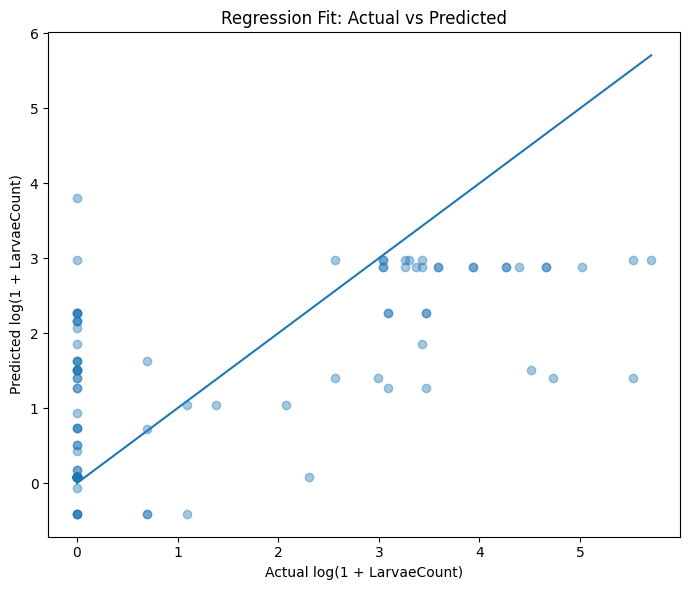

In [99]:
df_reg["pred_log_larvae"] = model.predict(df_reg)

plt.figure(figsize=(7, 6))
plt.scatter(df_reg["log_larvae"], df_reg["pred_log_larvae"], alpha=0.4)
plt.xlabel("Actual log(1 + LarvaeCount)")
plt.ylabel("Predicted log(1 + LarvaeCount)")
plt.title("Regression Fit: Actual vs Predicted")
plt.plot([df_reg["log_larvae"].min(), df_reg["log_larvae"].max()],
         [df_reg["log_larvae"].min(), df_reg["log_larvae"].max()])
plt.tight_layout()
plt.show()

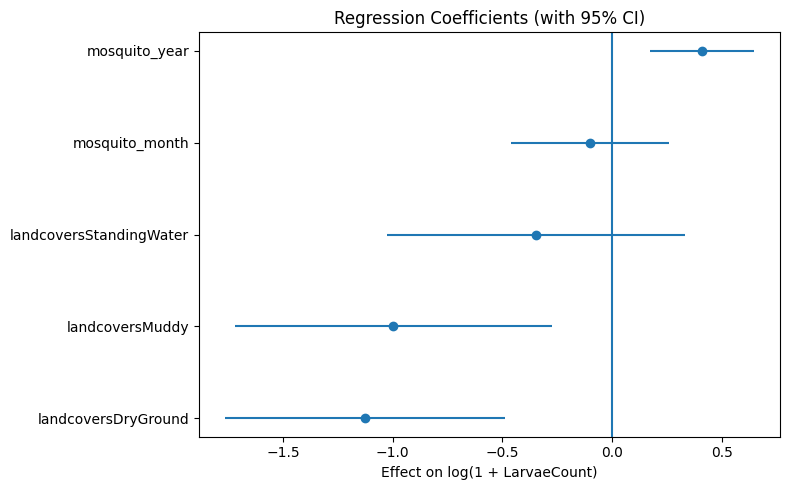

In [100]:
params = model.params
conf = model.conf_int()
conf.columns = ["low", "high"]

coef_df = pd.DataFrame({
    "coef": params,
    "low": conf["low"],
    "high": conf["high"]
}).drop("Intercept", errors="ignore")

coef_df = coef_df.sort_values("coef")

plt.figure(figsize=(8, 5))
plt.errorbar(
    coef_df["coef"],
    range(len(coef_df)),
    xerr=[coef_df["coef"] - coef_df["low"], coef_df["high"] - coef_df["coef"]],
    fmt="o"
)
plt.yticks(range(len(coef_df)), coef_df.index)
plt.axvline(0)
plt.title("Regression Coefficients (with 95% CI)")
plt.xlabel("Effect on log(1 + LarvaeCount)")
plt.tight_layout()
plt.show()

In [104]:
land_cover[1:100]
land_cover[2,]

,countryCode,countryName,elevation,landcoversDataSource,landcoversDownwardCaption,landcoversDownwardExtraData,landcoversDownwardPhotoUrl,landcoversDryGround,landcoversEastCaption,landcoversEastClassifications,landcoversEastExtraData,landcoversEastPhotoUrl,landcoversFeature1Caption,landcoversFeature1ExtraData,landcoversFeature1PhotoUrl,landcoversFeature2Caption,landcoversFeature2ExtraData,landcoversFeature2PhotoUrl,landcoversFeature3Caption,landcoversFeature3ExtraData,landcoversFeature3PhotoUrl,landcoversFeature4Caption,landcoversFeature4ExtraData,landcoversFeature4PhotoUrl,landcoversFieldNotes,landcoversGlobeTeams,landcoversLandCoverId,landcoversLeavesOnTrees,landcoversLocationAccuracyM,landcoversLocationMethod,landcoversMeasuredAt,landcoversMeasurementElevation,landcoversMeasurementLatitude,landcoversMeasurementLongitude,landcoversMucCode,landcoversMucDescription,landcoversMucDetails,landcoversMuddy,landcoversNorthCaption,landcoversNorthClassifications,landcoversNorthExtraData,landcoversNorthPhotoUrl,landcoversRainingSnowing,landcoversSnowIce,landcoversSouthCaption,landcoversSouthClassifications,landcoversSouthExtraData,landcoversSouthPhotoUrl,landcoversStandingWater,landcoversUpwardCaption,landcoversUpwardExtraData,landcoversUpwardPhotoUrl,landcoversUserid,landcoversWestCaption,landcoversWestClassifications,landcoversWestExtraData,landcoversWestPhotoUrl,organizationId,organizationName,protocol,siteId,siteName,geometry
1,USA,United States,2.9,GLOBE Observer App,null,null,pending approval,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89458,true,32,automatic,2026-01-31 03:02:00.000,4.3,21.3173,-157.8621,null,null,,false,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178386707,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409681,04QFJ180576,POINT (-157.86225 21.31648)
2,USA,United States,265.1,GLOBE Observer App,null,null,https://data.globe.gov/system/photos/2026/01/3...,false,null,null,null,pending approval,null,null,null,null,null,null,null,null,null,null,null,null,(none),None,89457,true,25,automatic,2026-01-31 00:19:00.000,271,21.4798,-157.9967,null,null,,true,null,null,null,pending approval,true,false,null,null,null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178357780,null,null,null,pending approval,17043304,United States of America Citizen Science,land_covers,409676,04QFJ039755,POINT (-157.99708 21.47905)
3,USA,United States,7.9,GLOBE Data Entry Site Definition,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,None,89460,null,null,null,2026-01-31 03:49:22.993,None,None,None,M9,Urban,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,17043304,United States of America Citizen Science,land_covers,409682,Park,POINT (-158.0261 21.325)
4,USA,United States,159.2,GLOBE Observer App,null,null,pending approval,false,null,"60% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,https://data.globe.gov/system/photos/2026/01/3...,null,null,null,null,null,null,null,null,null,null,null,null,(none),[Oregon State University GEOGRAPHY],89456,true,12,automatic,2026-01-31 00:26:00.000,152.7,47.428,-122.0285,M43,"Herbaceous/Grassland, Short Grass",,true,null,"70% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,https://data.globe.gov/system/photos/2026/01/3...,true,false,null,"50% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,pending approval,false,null,null,https://data.globe.gov/system/photos/2026/01/3...,178086139,null,"80% MUC 43 [Herbaceous/Grassland, Short Grass]...",null,pending approval,17043304,United States of America Citizen Science,land_covers,409675,10TET732531,POINT (-122.0294 47.42724)
5,UKR,Ukraine,141.7,GLOBE Observer App,null,null,null,false,null,null,null,null,null,null